In [ ]:
import pandas as pd, yfinance as yf, numpy as np, pandas_datareader.data as web
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas_datareader as web
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import scipy.optimize as sco
import seaborn as sns
import statsmodels.api as sm

In [ ]:
start = '2010-01-01'
end = '2025-05-01'

In [ ]:
sp = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]
sp.columns= sp.columns.str.replace(' ','_').str.lower()
list = sp[sp["gics_sector"]== 'Communication Services']['symbol'].to_list()
returns = yf.download(list, start=start,end=end)['Close'].pct_change()[1:]

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  23 of 23 completed


In [ ]:
#Winsorization - removing the influence of extreme high and extreme low values
returns = returns.clip(lower=returns.quantile(q=.05),
                       upper=returns.quantile(q=.95),
                       axis=1)
#Removing stocks not having data of at least 95% to the time period
returns = returns.dropna(thresh=int(returns.shape[0] * .95), axis=1)
#Removing trading days not having data of atleast 95% of the stocks
returns = returns.dropna(thresh=int(returns.shape[1] * .95))

In [ ]:
avg_ret = returns.mean(1)
returns = returns.apply(lambda x: x.fillna(avg_ret))
pca = PCA().fit(returns)
components = pd.DataFrame(pca.components_, columns = returns.columns)
explained_variances = pca.explained_variance_ratio_
cumulative_variances = np.cumsum(explained_variances)

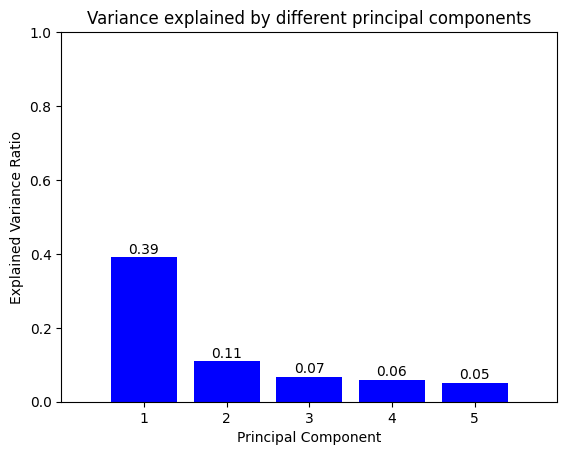

In [ ]:
plt.bar(x = range(1,6), height=explained_variances[:5],color='blue')
plt.title('Variance explained by different principal components')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
for i, v in enumerate(explained_variances[:5]):
    plt.text(i + 1, v + 0.01, f'{v:.2f}', ha='center')

plt.xticks(range(1,6))
plt.xlim(0,6)
plt.ylim(0,1)
plt.show()

In [ ]:
pc1 = pd.Series(index=returns.columns, data = pca.components_[0])
spy = yf.download('SPY', start=start, end=end)['Close'].pct_change()[1:]
merged = pd.merge(pc1.to_frame(),sp[['gics_sector','symbol']],
                  left_index=True,right_on='symbol',how='inner').set_index('symbol').\
                  rename(columns = {0:'pc1'})
pc_small = merged.nsmallest(10,'pc1')
pc_large = merged.nlargest(10,'pc1')

[*********************100%***********************]  1 of 1 completed


In [ ]:
ret_h = returns[pc_large.index].mean(1)
cret_h = ret_h.cumsum().apply(np.exp)
ret_l = returns[pc_small.index].mean(1)
cret_l = ret_l.cumsum().apply(np.exp)
ret_sec = returns[merged.index].mean(1)
cret_sec = ret_sec.cumsum().apply(np.exp)
cret_mkt = spy.cumsum().apply(np.exp)

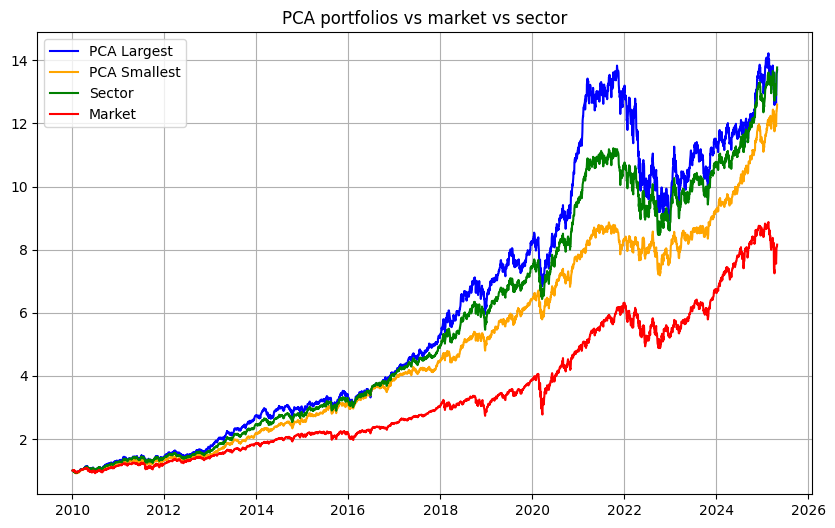

In [ ]:
plt.figure(figsize=(10, 6))

# Plot each line with a label and optional color
plt.plot(cret_h, label='PCA Largest', color='blue')
plt.plot(cret_l, label='PCA Smallest', color='orange')
plt.plot(cret_sec, label='Sector', color='green')
plt.plot(cret_mkt, label='Market', color='red')

# Title, legend, and show
plt.title('PCA portfolios vs market vs sector')
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
#4

In [ ]:
funda = pd.read_csv("funda_sp_selected.csv")

In [ ]:
funda_sp = pd.merge(funda, sp[['gics_sector','symbol']],left_on='tic',right_on='symbol',how='left')


In [ ]:
funda_sp = funda_sp.\
    assign(current_ratio=lambda x: x['act'] / x['dlc']).\
    assign(current_ratio_avg=lambda x: x.groupby('gvkey')['current_ratio'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)).\
    assign(debt_ratio=lambda x: x['dltt'] / x['at']).\
    assign(debt_ratio_avg=lambda x: x.groupby('gvkey')['debt_ratio'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)).\
    assign(roa=lambda x: x['ni'] / x['at']).\
    assign(roa_avg=lambda x: x.groupby('gvkey')['roa'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)).\
    assign(profit_margin=lambda x: x['ni'] / x['sale']).\
    assign(profit_margin_avg=lambda x: x.groupby('gvkey')['profit_margin'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True))






In [ ]:
# get the latest value
funda_sp1 = funda_sp.sort_values(['gvkey','fyear']).groupby('gvkey').tail(1).reset_index()

In [ ]:
pc_large_companies = [index for index, row in funda_sp1.iterrows() if row['tic'] in pc_large.index.to_list()]
pc_large_df = funda_sp1.iloc[pc_large_companies]
best_pc_large_companies = pc_large_df.nlargest(8, ['roa_avg'])\
.nlargest(6, 'current_ratio_avg')\
.nlargest(5, 'profit_margin_avg')\
.nsmallest(4, 'debt_ratio_avg')['symbol'].to_list()

In [ ]:
best_pc_large_companies

['GOOGL', 'IPG', 'NFLX', 'LYV']

In [ ]:
pc_small_companies = [index for index, row in funda_sp1.iterrows() if row['tic'] in pc_small.index.to_list()]
pc_small_df = funda_sp1.iloc[pc_small_companies]
best_pc_small_companies = pc_small_df.nlargest(8, ['roa_avg'])\
.nlargest(6, 'current_ratio_avg')\
.nlargest(5, 'profit_margin_avg')\
.nsmallest(4, 'debt_ratio_avg')['symbol'].to_list()

In [ ]:
best_pc_small_companies

['GOOGL', 'EA', 'OMC', 'TKO']

In [ ]:
pc_large

,pc1,gics_sector
symbol,,
WBD,0.326130,Communication Services
PARA,0.313636,Communication Services
NFLX,0.305318,Communication Services
MTCH,0.289247,Communication Services
LYV,0.289170,Communication Services
IPG,0.256407,Communication Services
TTWO,0.250804,Communication Services
GOOG,0.220038,Communication Services
GOOGL,0.219991,Communication Services


In [ ]:
pc_small

,pc1,gics_sector
symbol,,
VZ,0.092248,Communication Services
T,0.114542,Communication Services
CHTR,0.188064,Communication Services
TMUS,0.191968,Communication Services
OMC,0.197959,Communication Services
CMCSA,0.203261,Communication Services
TKO,0.206254,Communication Services
EA,0.214485,Communication Services
DIS,0.215437,Communication Services


In [ ]:
#5

n_portfolios = 10**5
n_days = 252
returns = yf.download(best_pc_large_companies, start=start, end=end)['Close'].pct_change().dropna()
avg_returns = returns.mean()*n_days
cov_matrix = returns.cov()*n_days
n_tickers = len(best_pc_large_companies)
np.random.seed(50)
weights = np.random.random(size=(n_portfolios, n_tickers))
weights /=  np.sum(weights, axis=1)[:, np.newaxis]
initial_columns = returns.columns

[*********************100%***********************]  4 of 4 completed


In [ ]:
# Calculate the weighted average portfolio returns
portfolio_returns = np.dot(weights, avg_returns)

portfolio_volatility = []

for i in range(0, len(weights)):
    portfolio_volatility.append(
        np.sqrt(np.dot(weights[i].T, np.dot(cov_matrix, weights[i]
            )
            )
            )
        )

portfolio_results = pd.DataFrame(
    {'returns': portfolio_returns,
     'volatility': np.array(portfolio_volatility),
     'Sharpe_ratio': portfolio_returns / np.array(portfolio_volatility)
     }
    )

In [ ]:
# Create functions needed later generate efficient frontier
def generate_portfolio_returns(w, avg_returns):
    return np.sum(avg_returns*w)

def generate_portfolio_volatility(w, avg_returns, cov_matrix):
    return np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))

def generate_efficient_frontier(avg_returns, cov_matrix, returns_range):
    efficient_portfolios = []
    n_tickers = len(avg_returns)
    inputs = (avg_returns, cov_matrix)
    bounds = tuple((0,1) for ticker in range(n_tickers))  #Determining the bounds of weights
    initial_input = n_tickers*[1./n_tickers,]
    #Note here: 1./n_tickers, repeated n_tickers times; initially we started with equal weights
    for ret in returns_range:
        constraints = (
            {'type':'eq',
                        'fun' : lambda x: generate_portfolio_returns(x, avg_returns) - ret},
                       {'type' : 'eq', #Constraint type is equaliy
                        'fun' : lambda x: np.sum(x) - 1}
            )
        efficient_portfolio = sco.minimize(
            generate_portfolio_volatility, initial_input, args = inputs , method = 'SLSQP',
            #SLSQP = Sequential Least Squares Programming Method
            constraints = constraints,
            bounds = bounds)
        efficient_portfolios.append(efficient_portfolio)

    return efficient_portfolios

In [ ]:
returns_range = np.linspace(min(avg_returns), max(avg_returns), 200) #200 equally spaced target returns between -0.5 and 0.5. Note that we can change it based on our projection

efficient_portfolios = generate_efficient_frontier(avg_returns,
                                                   cov_matrix,
                                                   returns_range)

volatility_range = [x['fun'] for x in efficient_portfolios]

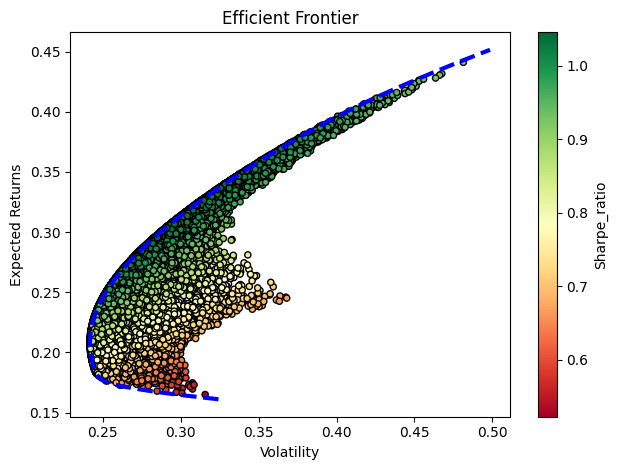

In [ ]:
fig, ax = plt.subplots()
portfolio_results.plot(kind = 'scatter',
                       x = 'volatility',
                       y = 'returns',
                       c = 'Sharpe_ratio',
                       cmap='RdYlGn', edgecolors='black',
                       ax = ax)
ax.plot(volatility_range, returns_range, 'b--', linewidth = 3) # b-- means blue line with line style --
ax.set(xlabel = 'Volatility',
       ylabel = 'Expected Returns',
       title = 'Efficient Frontier')
plt.tight_layout()
plt.show()

In [ ]:
min_vol = np.argmin(volatility_range) #Identifying index number or position of the minimum variance portfolio
min_vol_portfolio_return = returns_range[min_vol] #Return corresponding to minimum variance
min_vol_portoflio_volatility = efficient_portfolios[min_vol]['fun'] #the minimum variance in the efficient frontier

min_vol_portf = {'Return': min_vol_portfolio_return,
                 'Volatility': min_vol_portoflio_volatility,
                 'Sharpe_ratio': (min_vol_portfolio_return/min_vol_portoflio_volatility)
    }


In [ ]:
for x, y in zip(best_pc_large_companies, efficient_portfolios[min_vol]['x']):
    print(f'{x}: {100*y:.2f}% ', end="", flush=True)

GOOGL: 51.97% IPG: 28.82% NFLX: 11.80% LYV: 7.41% 

In [ ]:
weights_df = pd.DataFrame.from_dict(dict(zip(best_pc_large_companies, efficient_portfolios[min_vol]['x'])),
 orient='index',
 columns=['Weight'])
aligned_weights = weights_df['Weight'].reindex(initial_columns, fill_value=0)
returns['portfolio_returns'] = (returns * aligned_weights).sum(axis=1)
equal_weights = pd.Series(1/len(initial_columns), index=initial_columns, name='Weight')
returns['portfolio_returns_eq'] = (returns * equal_weights).sum(axis=1)

In [ ]:
equal_weights

Ticker
GOOGL    0.25
IPG      0.25
LYV      0.25
NFLX     0.25
Name: Weight, dtype: float64

In [ ]:
returns

Ticker,GOOGL,IPG,LYV,NFLX,portfolio_returns,portfolio_returns_eq
Date,,,,,,
2010-01-05,-0.004404,-0.010624,0.025219,-0.036836,-0.007826,-0.006661
2010-01-06,-0.025209,0.000000,0.064171,0.035139,-0.004200,0.018525
2010-01-07,-0.023280,-0.025503,-0.025126,-0.017254,-0.023346,-0.022791
2010-01-08,0.013331,0.001377,-0.006186,0.017176,0.008893,0.006425
2010-01-11,-0.001512,0.027510,-0.030083,-0.001313,0.004757,-0.001349
...,...,...,...,...,...,...
2025-04-23,0.025616,0.003766,0.021634,0.008891,0.017051,0.014977
2025-04-24,0.025298,0.045436,0.010969,0.045046,0.032368,0.031687
2025-04-25,0.016826,-0.020734,0.000301,0.004248,0.003294,0.000160


In [ ]:
#6
n_portfolios = 10**5
n_days = 252
returns1 = yf.download(best_pc_small_companies, start=start, end=end)['Close'].pct_change().dropna()
avg_returns = returns1.mean()*n_days
cov_matrix = returns1.cov()*n_days
n_tickers = len(best_pc_small_companies)
np.random.seed(50)
weights = np.random.random(size=(n_portfolios, n_tickers))
weights /=  np.sum(weights, axis=1)[:, np.newaxis]
initial_columns = returns1.columns


[*********************100%***********************]  4 of 4 completed


In [ ]:
# Calculate the weighted average portfolio returns
portfolio_returns = np.dot(weights, avg_returns)

portfolio_volatility = []

for i in range(0, len(weights)):
    portfolio_volatility.append(
        np.sqrt(np.dot(weights[i].T, np.dot(cov_matrix, weights[i]
            )
            )
            )
        )

portfolio_results = pd.DataFrame(
    {'returns': portfolio_returns,
     'volatility': np.array(portfolio_volatility),
     'Sharpe_ratio': portfolio_returns / np.array(portfolio_volatility)
     }
    )

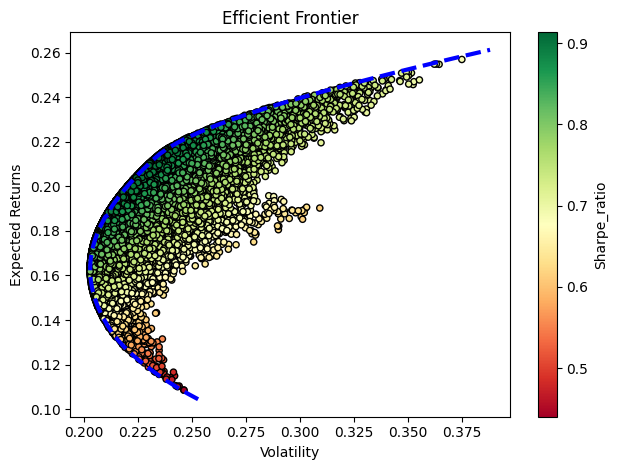

In [ ]:
returns_range = np.linspace(min(avg_returns), max(avg_returns), 200) #200 equally spaced target returns between -0.5 and 0.5. Note that we can change it based on our projection

efficient_portfolios = generate_efficient_frontier(avg_returns,
                                                   cov_matrix,
                                                   returns_range)

volatility_range = [x['fun'] for x in efficient_portfolios]
fig, ax = plt.subplots()
portfolio_results.plot(kind = 'scatter',
                       x = 'volatility',
                       y = 'returns',
                       c = 'Sharpe_ratio',
                       cmap='RdYlGn', edgecolors='black',
                       ax = ax)
ax.plot(volatility_range, returns_range, 'b--', linewidth = 3) # b-- means blue line with line style --
ax.set(xlabel = 'Volatility',
       ylabel = 'Expected Returns',
       title = 'Efficient Frontier')
plt.tight_layout()
plt.show()

In [ ]:
min_vol = np.argmin(volatility_range) #Identifying index number or position of the minimum variance portfolio
min_vol_portfolio_return = returns_range[min_vol] #Return corresponding to minimum variance
min_vol_portoflio_volatility = efficient_portfolios[min_vol]['fun'] #the minimum variance in the efficient frontier

min_vol_portf = {'Return': min_vol_portfolio_return,
                 'Volatility': min_vol_portoflio_volatility,
                 'Sharpe_ratio': (min_vol_portfolio_return/min_vol_portoflio_volatility)
    }

for x, y in zip(best_pc_small_companies, efficient_portfolios[min_vol]['x']):
    print(f'{x}: {100*y:.2f}% ', end="", flush=True)

GOOGL: 20.28% EA: 27.17% OMC: 41.10% TKO: 11.45% 

In [ ]:
weights_df = pd.DataFrame.from_dict(dict(zip(best_pc_small_companies, efficient_portfolios[min_vol]['x'])),
 orient='index',
 columns=['Weight'])

In [ ]:
aligned_weights = weights_df['Weight'].reindex(initial_columns, fill_value=0)
equal_weights = pd.Series(1/len(initial_columns), index=initial_columns, name='Weight')
# Create equally weighted portfolio weights
returns1['portfolio_returns_eq'] = (returns1 * equal_weights).sum(axis=1)
returns1['portfolio_returns'] = (returns1 * aligned_weights).sum(axis=1)


In [ ]:
equal_weights

Ticker
EA       0.25
GOOGL    0.25
OMC      0.25
TKO      0.25
Name: Weight, dtype: float64

In [ ]:
returns1

Ticker,EA,GOOGL,OMC,TKO,portfolio_returns_eq,portfolio_returns
Date,,,,,,
2010-01-05,0.028099,-0.004404,-0.003533,0.021154,0.010329,0.007711
2010-01-06,-0.025724,-0.025209,-0.007853,0.007533,-0.012813,-0.014467
2010-01-07,-0.007701,-0.023280,-0.005871,0.014330,-0.005630,-0.007587
2010-01-08,0.019956,0.013331,0.011556,0.001228,0.011518,0.013016
2010-01-11,-0.007065,-0.001511,0.000000,-0.019632,-0.007052,-0.004473
...,...,...,...,...,...,...
2025-04-23,-0.014671,0.025616,-0.000273,0.019307,0.007495,0.003307
2025-04-24,0.017115,0.025298,0.042594,0.028412,0.028355,0.030540
2025-04-25,0.002805,0.016826,-0.018987,0.011721,0.003091,-0.002287


In [ ]:
returns

Ticker,GOOGL,IPG,LYV,NFLX,portfolio_returns,portfolio_returns_eq
Date,,,,,,
2010-01-05,-0.004404,-0.010624,0.025219,-0.036836,-0.016031,-0.008535
2010-01-06,-0.025209,0.000000,0.064171,0.035139,0.016675,0.018155
2010-01-07,-0.023279,-0.025503,-0.025126,-0.017254,-0.021619,-0.022556
2010-01-08,0.013331,0.001377,-0.006186,0.017176,0.009429,0.007025
2010-01-11,-0.001511,0.027510,-0.030083,-0.001313,0.003185,-0.000443
...,...,...,...,...,...,...
2025-04-23,0.025616,0.003766,0.021634,0.008891,0.012350,0.014451
2025-04-24,0.025298,0.045436,0.010969,0.045046,0.037245,0.032799
2025-04-25,0.016826,-0.020734,0.000301,0.004248,-0.000441,0.000040


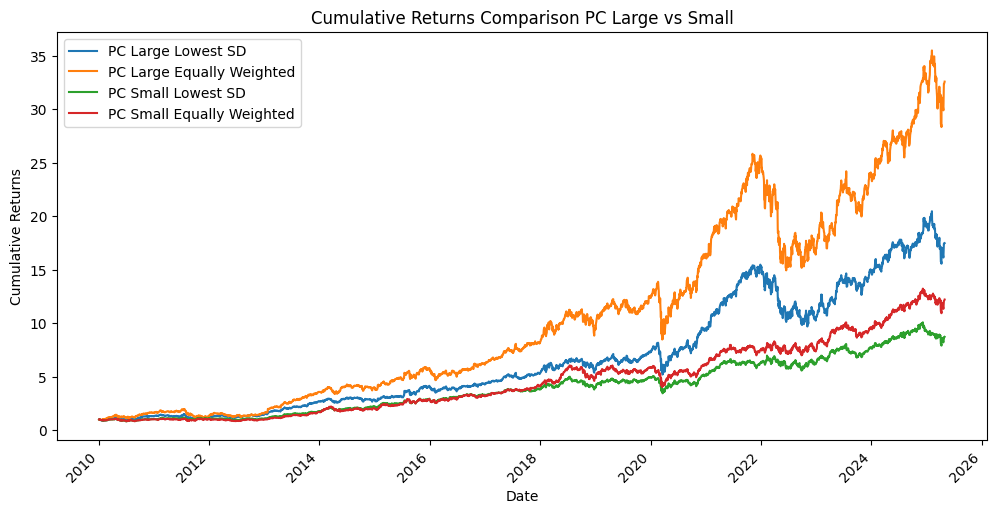

In [ ]:
# Create separate series for each portfolio's daily returns
ret_pcllsd = returns['portfolio_returns']
ret_pcleq = returns['portfolio_returns_eq']
ret_pcslsd = returns1['portfolio_returns']
ret_pcseq = returns1['portfolio_returns_eq']

# Calculate cumulative returns
cumulative_pcllsd = (1 + ret_pcllsd).cumprod()
cumulative_pcleq = (1 + ret_pcleq).cumprod()
cumulative_pcslsd = (1 + ret_pcslsd).cumprod()
cumulative_pcseq = (1 + ret_pcseq).cumprod()

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))
cumulative_pcllsd.plot(ax=ax, label='PC Large Lowest SD')
cumulative_pcleq.plot(ax=ax, label='PC Large Equally Weighted')
cumulative_pcslsd.plot(ax=ax, label='PC Small Lowest SD')
cumulative_pcseq.plot(ax=ax, label='PC Small Equally Weighted')

# Set plot properties
ax.set_title('Cumulative Returns Comparison PC Large vs Small')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Returns')
ax.legend()
plt.xticks(rotation=45)
plt.show()

[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  1 of 1 completed
C:\Users\12039\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pyfolio\plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '25.5%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2010-01-05
End date,2025-04-30
Total months,183
,Backtest
Annual return,25.5%
Cumulative returns,3125.813%
Annual volatility,26.184%
Sharpe ratio,1.00
Calmar ratio,0.60
Stability,0.96
Max drawdown,-42.171%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,42.17,2021-11-05,2022-06-16,2024-03-12,613
1,41.69,2011-07-22,2011-11-25,2013-01-25,396
2,38.89,2020-02-19,2020-03-18,2020-08-27,137
3,22.51,2010-04-26,2010-07-02,2010-09-27,111
4,21.80,2018-10-03,2018-12-24,2019-03-01,108


C:\Users\12039\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pyfolio\plotting.py:1407: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Daily", "Weekly", "Monthly"])
C:\Users\12039\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pyfolio\plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '17.689%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2010-01-05
End date,2025-04-30
Total months,183
,Backtest
Annual return,17.689%
Cumulative returns,1107.35%
Annual volatility,21.141%
Sharpe ratio,0.88
Calmar ratio,0.54
Stability,0.97
Max drawdown,-32.985%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,32.98,2018-07-16,2020-03-16,2020-12-15,632
1,21.63,2011-07-22,2012-06-26,2013-02-01,401
2,21.04,2010-04-23,2010-08-24,2011-03-03,225
3,20.98,2014-03-18,2014-05-19,2015-02-12,238
4,17.36,2024-12-06,2025-04-08,NaT,NaN


C:\Users\12039\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pyfolio\plotting.py:1407: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Daily", "Weekly", "Monthly"])


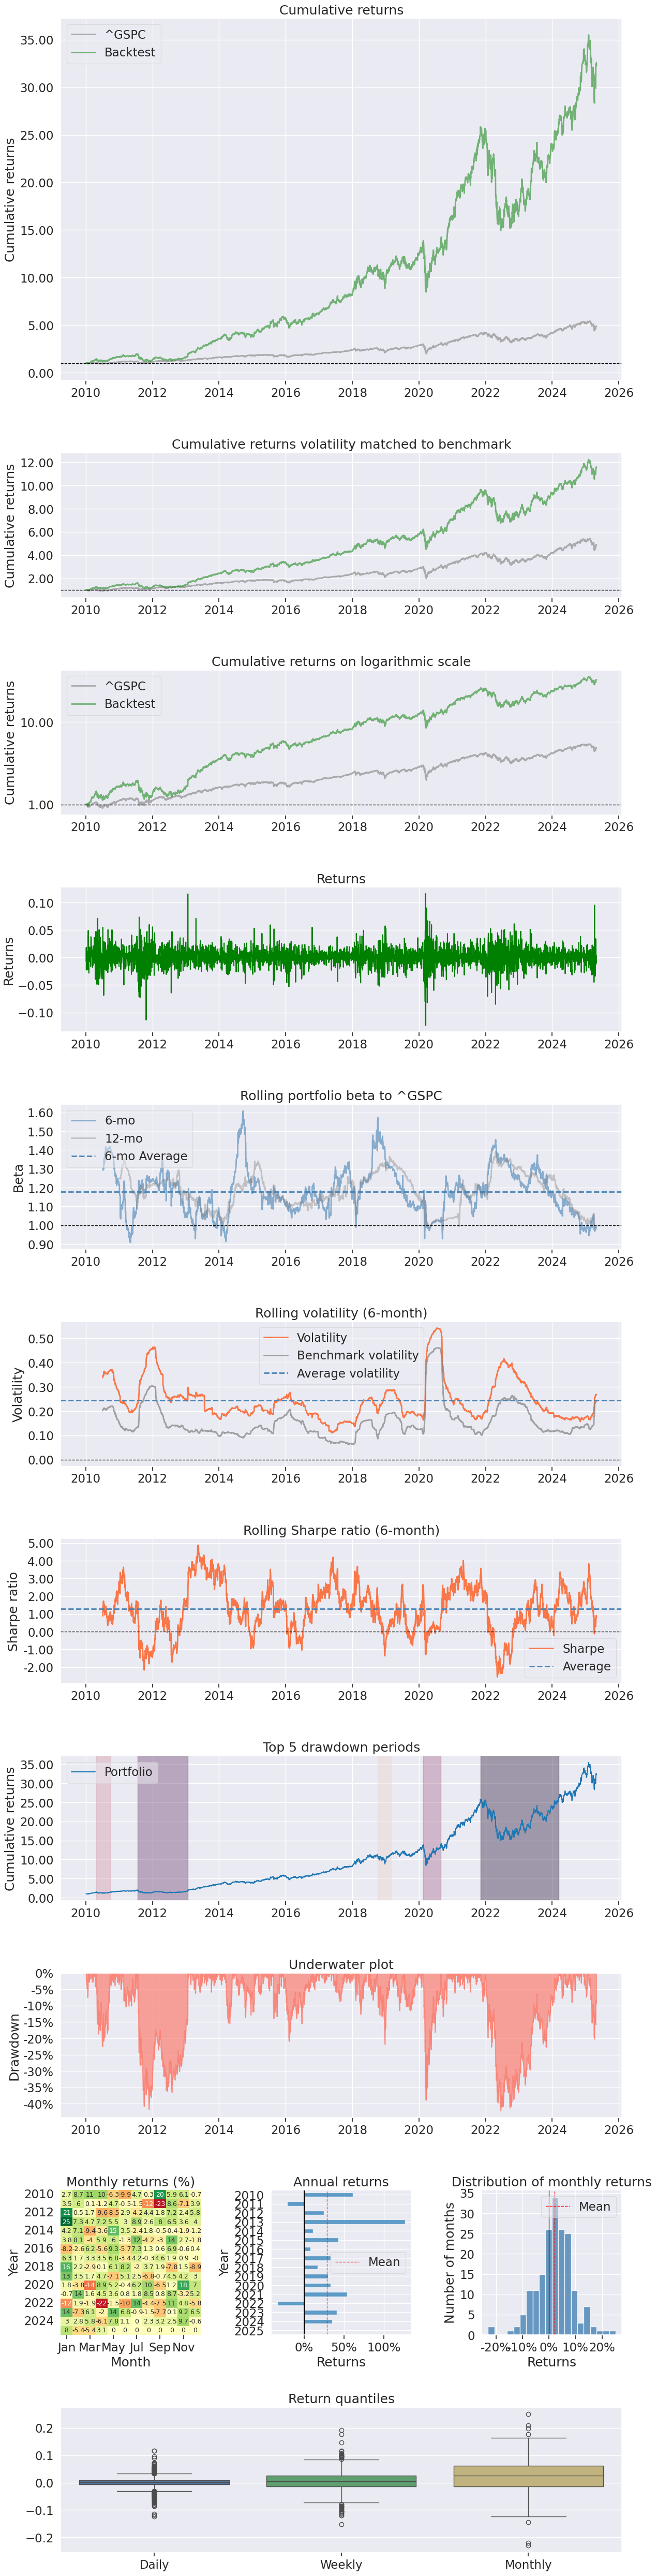

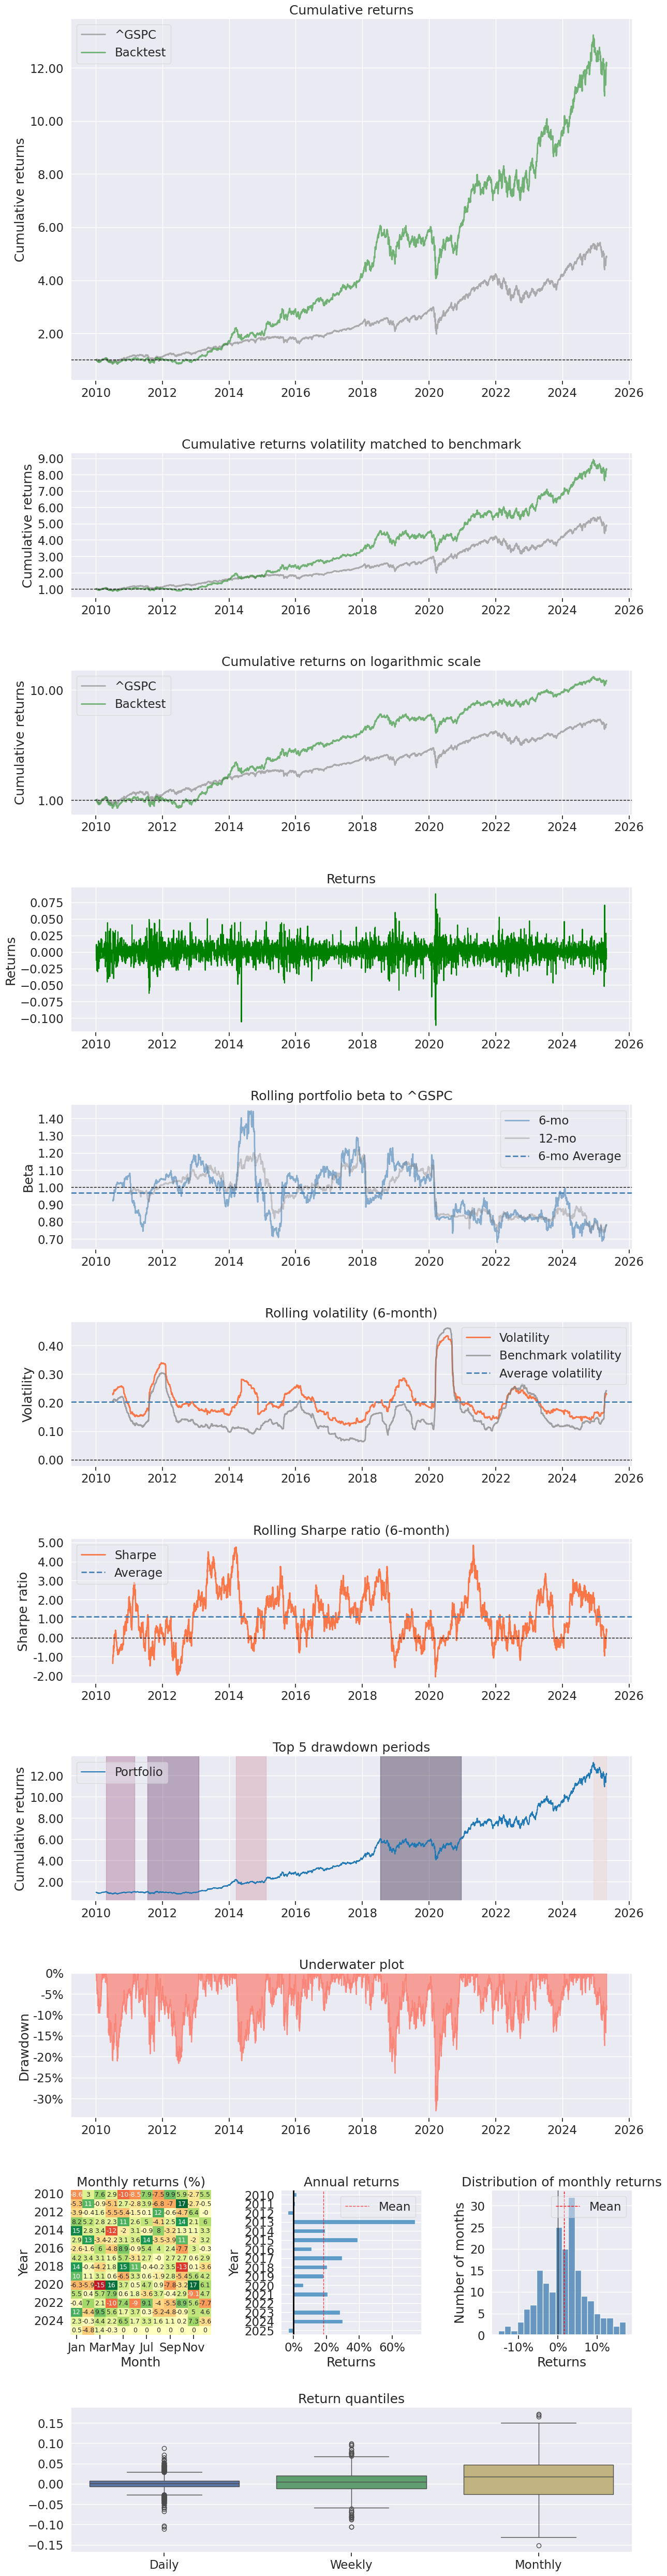

In [ ]:
#8
# !pip install pyfolio-reloaded
import pyfolio as pf
pcl_returns = yf.download(best_pc_large_companies, start=start,
                      end=end)['Close'].pct_change()[1:]
pcs_returns = yf.download(best_pc_small_companies, start=start,
                      end=end)['Close'].pct_change()[1:]

pcl_returns['portfolio_equal'] = pcl_returns.mean(axis=1)
pcs_returns['portfolio_equal'] = pcs_returns.mean(axis=1)

# Convert it to a pandas series to run Pyfolio later
pcl_rets = pcl_returns['portfolio_equal']
pcs_rets = pcs_returns['portfolio_equal']
spy = yf.download('^GSPC', start=start,
                      end=end)['Close'].pct_change()[1:]
spy = spy['^GSPC']

fig1 = pf.create_returns_tear_sheet(pcl_rets, benchmark_rets=spy, return_fig=True)
fig2 = pf.create_returns_tear_sheet(pcs_rets, benchmark_rets=spy, return_fig=True)